# Validation Train Split Notebook for Tweedy et al., 2026

In [47]:
""" Created on March 3, 2023 // @authora: Ruth Tweedy """

' Created on March 3, 2023 // @authora: Ruth Tweedy '

This notebook reads in the dataset associated with Tweedy et al., 2026 ("All_Africa_ML_dataset_.csv") and generates a "test_train_df.csv" which contains the same data, normalized, split into validationa nd training datasets, synthetically augmented to even the size of woody and grassy samples, and center log-ratio transformed. This datset will be read into the Machine Leaning Model scripts to train and validate the models.

# Setting Up Notebook

In [1]:
import numpy as np
import pandas as pd

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns

from composition_stats import clr

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rc('font',**{'family':'Avenir', 'size': 20})
plt.rcParams['pdf.fonttype'] = 42

# Specifying Run Parameters

This is currently configured to create the standard test_train_df file. If you are instead choosing to run sensitivity tests, rename the output file and change the parameter you wish to change. If reducing training datset size, set keep_this_fraction to a number between 0-1. If running a different sensivitiy test, set run_XXX_sensitivity_test = True.

In [2]:
output_csv = 'test_train_df.csv'

keep_this_fraction = 1

run_C27_C35_sensitivity_test = False
run_Kakamega_sensitivity_test = False
run_Uno_only_sensitivity_test = False
run_woody_grassy_equal_sensitivity_test = False
run_no_shrubs_sensitivity_test = False

# Loading in & Editing Dataframe

In [3]:
min_df = pd.read_csv('All_Africa_ML_dataset.csv')
min_df

,source,ID,species,loc_sure,lon,lat,altitude,family,subfam,dom,...,C25,C27,C29,C31,C33,C35,ACL,CPI,Unnamed: 26,notes
0,This Study,KU819,Eragrostis sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.0209,0.0712,0.1042,0.2653,0.4917,0.0469,31.5527,15.887,NaN,NaN
1,This Study,KU820,Aristida sp. (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.0913,0.1630,0.1911,0.3577,0.1849,0.0120,29.8361,12.097,NaN,NaN
2,This Study,KU821,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.0582,0.1305,0.2178,0.4056,0.1759,0.0120,30.0927,13.514,NaN,NaN
3,This Study,KU823,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.0407,0.1131,0.2392,0.4232,0.1750,0.0088,30.2104,14.072,NaN,NaN
4,This Study,KU824,Aristida mutabilis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.1349,0.1896,0.1552,0.4056,0.1043,0.0105,29.3725,17.660,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,Vogts et al. (2009),NaN,Cynometra mannii,Y,10.370000,-2.953300,NaN,Fabaceae,NaN,A,...,0.0320,0.0330,0.8570,0.0730,0.0050,0.0000,28.9720,21.890,NaN,NaN
621,Vogts et al. (2009),NaN,Ficus ottoniifolia,Y,13.470000,0.850000,NaN,Moraceae,NaN,A,...,0.0190,0.0500,0.5580,0.3430,0.0290,0.0000,29.5970,14.660,NaN,NaN
622,Vogts et al. (2009),NaN,Psychotria djumaensis,Y,13.970000,1.012000,NaN,Rubiaceae,NaN,A,...,0.0060,0.0380,0.8290,0.1230,0.0040,0.0000,29.1620,26.800,NaN,NaN
623,Vogts et al. (2009),NaN,Treculia africana,Y,12.083000,-0.800000,NaN,Moraceae,NaN,A,...,0.0220,0.0600,0.5590,0.3220,0.0360,0.0000,29.5510,8.870,NaN,NaN


In [4]:
woody_options = ['Tree', 'Shrub']
grassy_options = ['Grass']

In [5]:
grassy_validation_samples = 45
woody_validation_samples = 90

In [6]:
all_alkanes = ['C25', 'C27', 'C29', 'C31', 'C33', 'C35']
alkanes = all_alkanes[1:] if run_C27_C35_sensitivity_test else all_alkanes

all_clrs = ['clr1', 'clr2', 'clr3', 'clr4', 'clr5', 'clr6']
clrs = all_clrs[:-1] if run_C27_C35_sensitivity_test else all_clrs

if run_Uno_only_sensitivity_test:
    min_df = min_df[min_df['source'].isin(['Tweedy et al. (2025)', 'This Study'])]
    grassy_validation_samples = 11
    woody_validation_samples = 22

if run_Kakamega_sensitivity_test:
    min_df.drop(min_df[min_df.regio == 'Kakamega'].index, inplace = True)

if run_no_shrubs_sensitivity_test:
    woody_options = ['Tree']
    grassy_validation_samples = 22
    woody_validation_samples = 45

if run_woody_grassy_equal_sensitivity_test:
    grassy_validation_samples = 22
    woody_validation_samples = 22

min_df

,source,ID,species,loc_sure,lon,lat,altitude,family,subfam,dom,...,C25,C27,C29,C31,C33,C35,ACL,CPI,Unnamed: 26,notes
0,This Study,KU819,Eragrostis sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.0209,0.0712,0.1042,0.2653,0.4917,0.0469,31.5527,15.887,NaN,NaN
1,This Study,KU820,Aristida sp. (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.0913,0.1630,0.1911,0.3577,0.1849,0.0120,29.8361,12.097,NaN,NaN
2,This Study,KU821,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.0582,0.1305,0.2178,0.4056,0.1759,0.0120,30.0927,13.514,NaN,NaN
3,This Study,KU823,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.0407,0.1131,0.2392,0.4232,0.1750,0.0088,30.2104,14.072,NaN,NaN
4,This Study,KU824,Aristida mutabilis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.1349,0.1896,0.1552,0.4056,0.1043,0.0105,29.3725,17.660,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,Vogts et al. (2009),NaN,Cynometra mannii,Y,10.370000,-2.953300,NaN,Fabaceae,NaN,A,...,0.0320,0.0330,0.8570,0.0730,0.0050,0.0000,28.9720,21.890,NaN,NaN
621,Vogts et al. (2009),NaN,Ficus ottoniifolia,Y,13.470000,0.850000,NaN,Moraceae,NaN,A,...,0.0190,0.0500,0.5580,0.3430,0.0290,0.0000,29.5970,14.660,NaN,NaN
622,Vogts et al. (2009),NaN,Psychotria djumaensis,Y,13.970000,1.012000,NaN,Rubiaceae,NaN,A,...,0.0060,0.0380,0.8290,0.1230,0.0040,0.0000,29.1620,26.800,NaN,NaN
623,Vogts et al. (2009),NaN,Treculia africana,Y,12.083000,-0.800000,NaN,Moraceae,NaN,A,...,0.0220,0.0600,0.5590,0.3220,0.0360,0.0000,29.5510,8.870,NaN,NaN


In [7]:
# Define a function to replace zero values with random numbers
def replace_zeros_with_random(df, columns, min_val, max_val):
    for column in columns:
        mask = (df[column] == 0)
        num_zeros = mask.sum()
        if num_zeros > 0:
            random_values = np.random.uniform(min_val, max_val, num_zeros)
            df.loc[mask, column] = random_values
    return df

In [8]:
# Replace zeros with random values
min_df = replace_zeros_with_random(min_df, alkanes, 0.000001, 0.0001)

In [9]:
min_df.pft.unique()

array(['Grass', 'Shrub', 'Tree'], dtype=object)

In [10]:
# Define a function to classify the entries
def classify_pft(pft):
    if pft in woody_options:
        return 'Woody'
    elif pft in grassy_options:
        return 'Grassy'
    else:
        return 'Unknown'

In [11]:
# Apply the function to create the 'class' column
min_df['wg'] = min_df['pft'].apply(classify_pft)

In [12]:
#Filter min_df to only include woody and grassy samples in this case, does nothing)
min_df = min_df[min_df['wg'].isin(['Woody', 'Grassy'])]

In [13]:
min_df

,source,ID,species,loc_sure,lon,lat,altitude,family,subfam,dom,...,C27,C29,C31,C33,C35,ACL,CPI,Unnamed: 26,notes,wg
0,This Study,KU819,Eragrostis sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.0712,0.1042,0.2653,0.4917,0.046900,31.5527,15.887,NaN,NaN,Grassy
1,This Study,KU820,Aristida sp. (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.1630,0.1911,0.3577,0.1849,0.012000,29.8361,12.097,NaN,NaN,Grassy
2,This Study,KU821,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.1305,0.2178,0.4056,0.1759,0.012000,30.0927,13.514,NaN,NaN,Grassy
3,This Study,KU823,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.1131,0.2392,0.4232,0.1750,0.008800,30.2104,14.072,NaN,NaN,Grassy
4,This Study,KU824,Aristida mutabilis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.1896,0.1552,0.4056,0.1043,0.010500,29.3725,17.660,NaN,NaN,Grassy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,Vogts et al. (2009),NaN,Cynometra mannii,Y,10.370000,-2.953300,NaN,Fabaceae,NaN,A,...,0.0330,0.8570,0.0730,0.0050,0.000005,28.9720,21.890,NaN,NaN,Woody
621,Vogts et al. (2009),NaN,Ficus ottoniifolia,Y,13.470000,0.850000,NaN,Moraceae,NaN,A,...,0.0500,0.5580,0.3430,0.0290,0.000022,29.5970,14.660,NaN,NaN,Woody
622,Vogts et al. (2009),NaN,Psychotria djumaensis,Y,13.970000,1.012000,NaN,Rubiaceae,NaN,A,...,0.0380,0.8290,0.1230,0.0040,0.000094,29.1620,26.800,NaN,NaN,Woody
623,Vogts et al. (2009),NaN,Treculia africana,Y,12.083000,-0.800000,NaN,Moraceae,NaN,A,...,0.0600,0.5590,0.3220,0.0360,0.000078,29.5510,8.870,NaN,NaN,Woody


In [14]:
min_df['photo_subfam'] = min_df['phototype'] + ' ' + min_df['subfam']
min_df['photo_subfam'].unique()

array(['C4 Aristidoideae', 'C3 Arundinoideae', 'C4 Chloridoideae',
       'C3 Danthonioideae', 'C3 Micrairoideae', 'C4 Panicoideae',
       'C3 Panicoideae', 'C3 Pharoideae', 'C3 Pooideae', 'C4 Pooideae',
       'C4 Unknown', 'C3 Unknown', nan], dtype=object)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def alkane_barplot_with_composition_bar(
    df,
    alkanes=alkanes,
    wg_col="wg",
    woody_label="Woody",
    grassy_label="Grassy",
    colors=None,
    figsize=(7,5),
    width=0.32,
    ylim=(0, 0.65),
    title=None,
    compbar_height=0.06,
    compbar_width=0.52,
    compbar_xy=(0.42, 0.92),
    compbar_fontsize=13,
    bar_alpha=0.85,
):
    if colors is None:
        colors = {woody_label: "darkgreen", grassy_label: "#FF9E00"}


    woody  = df[df[wg_col] == woody_label]
    grassy = df[df[wg_col] == grassy_label]

    n_w = len(woody)
    n_g = len(grassy)
    n_tot = n_w + n_g
    if n_tot == 0:
        raise ValueError("No Woody or Grassy samples in this dataset.")

    frac_w = n_w / n_tot
    frac_g = n_g / n_tot

    w_bar = np.array([woody[a].mean() for a in alkanes], dtype=float)
    w_std = np.array([woody[a].std(ddof=0) for a in alkanes], dtype=float)
    g_bar = np.array([grassy[a].mean() for a in alkanes], dtype=float)
    g_std = np.array([grassy[a].std(ddof=0) for a in alkanes], dtype=float)


    N = len(alkanes)
    ind = np.arange(N)
    fig, ax = plt.subplots(figsize=figsize)


    ax.bar(
        ind, w_bar, width,
        yerr=w_std,
        color=colors[woody_label],
        alpha=bar_alpha,
        align="edge",
        edgecolor="none",
        linewidth=0
    )

    ax.bar(
        ind + width, g_bar, width,
        yerr=g_std,
        color=colors[grassy_label],
        alpha=bar_alpha,
        align="edge",
        edgecolor="none",
        linewidth=0
    )

    ax.set_xlabel(r"$n$-Alkane Chain Length", fontsize=15, fontweight="bold")
    ax.set_ylabel("Relative Abundance", fontsize=15, fontweight="bold")
    if title:
        ax.set_title(title, fontsize=16)

    ax.set_xticks(ind + width/2)
    ax.set_xticklabels(alkanes, fontsize=15)
    ax.tick_params(axis="y", labelsize=15)
    
    left_edge  = ind.min()
    right_edge = (ind.max() + width) + width
    pad = 0.15
    ax.set_xlim(left_edge - pad, right_edge + pad)
    ax.set_ylim(*ylim)
    ax.set_yticks([0, 0.2, 0.4, 0.6])
    ax.set_yticklabels(["0", "0.2", "0.4", "0.6"], fontsize=15)

    x0, y0 = compbar_xy
    W = compbar_width
    H = compbar_height

    ax.add_patch(Rectangle(
        (x0, y0), W, H,
        transform=ax.transAxes,
        facecolor="none",
        edgecolor="black",
        linewidth=1.1,
        zorder=10,
        clip_on=False
    ))

    ax.add_patch(Rectangle(
        (x0, y0), W * frac_w, H,
        transform=ax.transAxes,
        facecolor=colors[woody_label],
        edgecolor="none", alpha=0.9,
        zorder=9,
        clip_on=False
    ))
    ax.add_patch(Rectangle(
        (x0 + W * frac_w, y0), W * frac_g, H,
        transform=ax.transAxes,
        facecolor=colors[grassy_label],
        edgecolor="none", alpha=0.9,
        zorder=9,
        clip_on=False
    ))

    woody_txt  = f"{woody_label} (n={n_w})"
    grassy_txt = f"{grassy_label} (n={n_g})"

    ax.text(
        x0, y0 + H + 0.01,
        woody_txt,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=compbar_fontsize,
        color="black",
        fontweight="bold",
        zorder=20
    )

    ax.text(
        x0 + W, y0 + H + 0.01,
        grassy_txt,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=compbar_fontsize,
        color="black",
        fontweight="bold",
        zorder=20
    )

    plt.show()
    return fig, ax

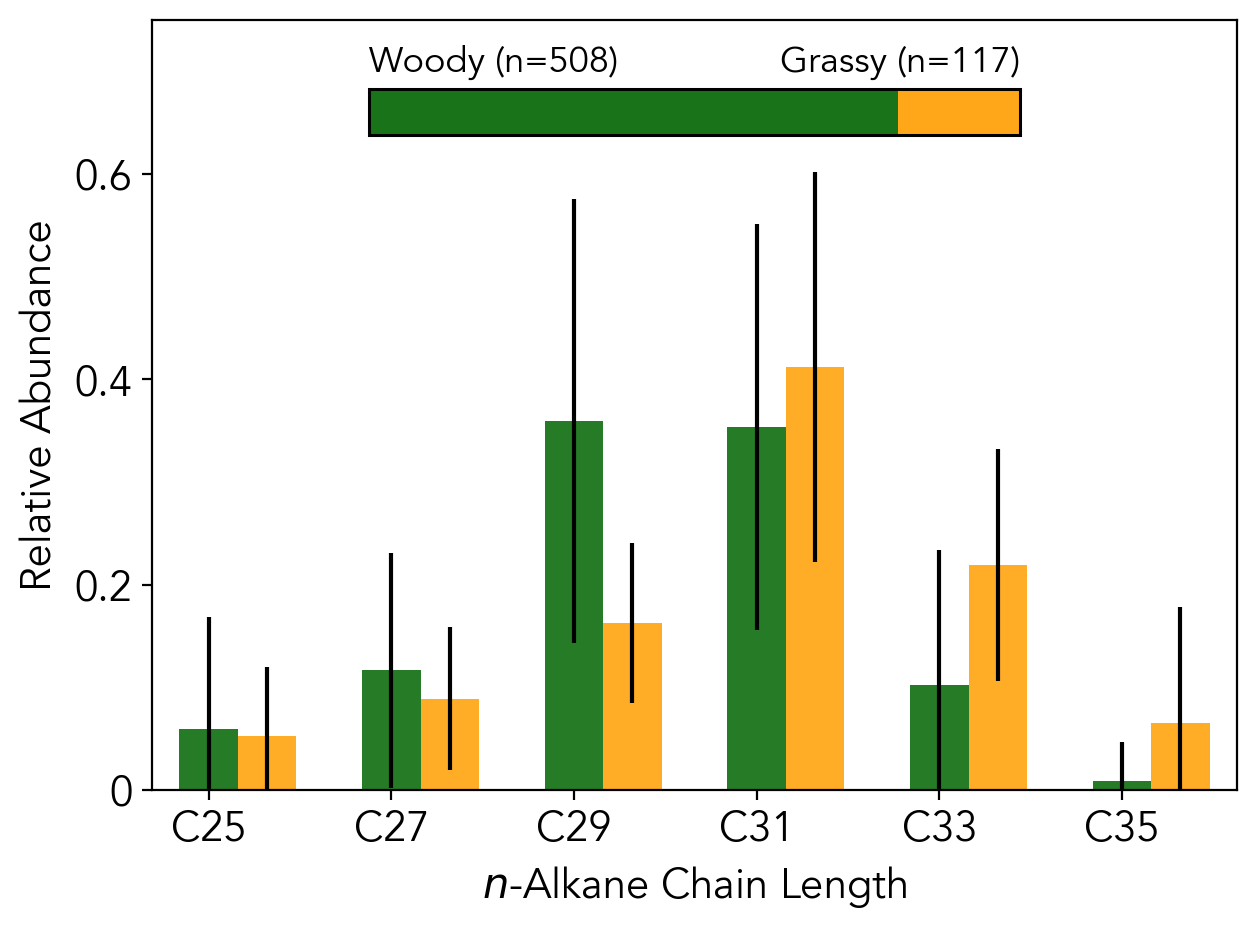

In [16]:
fig, ax = alkane_barplot_with_composition_bar(
    min_df,
    title=None,
    ylim=(0, 0.75),
    compbar_xy=(0.2, 0.85),
    compbar_width=0.6
)

plt.show()

## Optional Code for Sensitivity Testing ONLY

The code below can reduce the size of the larger category (i.e. woody plants) while maintaining the proportionality of a set column. Only runs for the run_woody_grassy_equal_sensitivity_test.

In [17]:
import pandas as pd

def balance_datasets(min_df, stratify_column):
 
    woody_df = min_df[min_df['wg'] == 'Woody']
    grassy_df = min_df[min_df['wg'] == 'Grassy']
    
    grassy_size = len(grassy_df)
    
    stratum_sizes = woody_df[stratify_column].value_counts()
    
    stratum_proportions = stratum_sizes / stratum_sizes.sum()
    
    sampled_rows = []
    for stratum_value, proportion in stratum_proportions.items():
        stratum_subset = woody_df[woody_df[stratify_column] == stratum_value]
        stratum_sample_size = int(proportion * grassy_size)
        
        stratum_sample = stratum_subset.sample(n=stratum_sample_size, random_state=42)
        sampled_rows.append(stratum_sample)
    
    reduced_woody_df = pd.concat(sampled_rows)
    
    balanced_df = pd.concat([reduced_woody_df, grassy_df], ignore_index=True)
    
    return balanced_df

if run_woody_grassy_equal_sensitivity_test:
    min_df = balance_datasets(min_df, 'pft')

min_df


,source,ID,species,loc_sure,lon,lat,altitude,family,subfam,dom,...,C29,C31,C33,C35,ACL,CPI,Unnamed: 26,notes,wg,photo_subfam
0,This Study,KU819,Eragrostis sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.1042,0.2653,0.4917,0.046900,31.5527,15.887,NaN,NaN,Grassy,C4 Aristidoideae
1,This Study,KU820,Aristida sp. (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.1911,0.3577,0.1849,0.012000,29.8361,12.097,NaN,NaN,Grassy,C4 Aristidoideae
2,This Study,KU821,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.2178,0.4056,0.1759,0.012000,30.0927,13.514,NaN,NaN,Grassy,C4 Aristidoideae
3,This Study,KU823,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.2392,0.4232,0.1750,0.008800,30.2104,14.072,NaN,NaN,Grassy,C4 Aristidoideae
4,This Study,KU824,Aristida mutabilis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.1552,0.4056,0.1043,0.010500,29.3725,17.660,NaN,NaN,Grassy,C4 Aristidoideae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,Vogts et al. (2009),NaN,Cynometra mannii,Y,10.370000,-2.953300,NaN,Fabaceae,NaN,A,...,0.8570,0.0730,0.0050,0.000005,28.9720,21.890,NaN,NaN,Woody,NaN
621,Vogts et al. (2009),NaN,Ficus ottoniifolia,Y,13.470000,0.850000,NaN,Moraceae,NaN,A,...,0.5580,0.3430,0.0290,0.000022,29.5970,14.660,NaN,NaN,Woody,NaN
622,Vogts et al. (2009),NaN,Psychotria djumaensis,Y,13.970000,1.012000,NaN,Rubiaceae,NaN,A,...,0.8290,0.1230,0.0040,0.000094,29.1620,26.800,NaN,NaN,Woody,NaN
623,Vogts et al. (2009),NaN,Treculia africana,Y,12.083000,-0.800000,NaN,Moraceae,NaN,A,...,0.5590,0.3220,0.0360,0.000078,29.5510,8.870,NaN,NaN,Woody,NaN


The code below is designed to re-format our dataframe to be summed between C27-C35. Only runs for the run_C27_C35_sensitivity_test.

In [18]:
def scale_columns(df, exclude_column, columns_to_scale):

    row_sum = df[columns_to_scale].sum(axis=1)
    
    row_sum = row_sum.replace(0, np.nan)
    
    df[columns_to_scale] = df[columns_to_scale].div(row_sum, axis=0)
    
    if exclude_column in df.columns:
        df = df.drop(columns=[exclude_column])
    
    return df

if run_C27_C35_sensitivity_test:
    min_df = scale_columns(min_df, 'C25', alkanes)

# Normalizing the Dataframe

In [19]:
label = ['wg']

wt = min_df[alkanes].fillna(0).to_numpy()

array_norm = clr(wt)
norm_df = pd.DataFrame(array_norm)

min_df[clrs] = norm_df

min_df

,source,ID,species,loc_sure,lon,lat,altitude,family,subfam,dom,...,Unnamed: 26,notes,wg,photo_subfam,clr1,clr2,clr3,clr4,clr5,clr6
0,This Study,KU819,Eragrostis sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,NaN,Grassy,C4 Aristidoideae,-1.556634,-0.330891,0.049928,0.984478,1.601485,-0.748366
1,This Study,KU820,Aristida sp. (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,NaN,Grassy,C4 Aristidoideae,-0.226702,0.352898,0.511944,1.138842,0.478963,-2.255946
2,This Study,KU821,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,NaN,Grassy,C4 Aristidoideae,-0.599286,0.208202,0.720406,1.342197,0.506745,-2.178264
3,This Study,KU823,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,NaN,Grassy,C4 Aristidoideae,-0.843636,0.178409,0.927436,1.497981,0.614922,-2.375112
4,This Study,KU824,Aristida mutabilis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,NaN,Grassy,C4 Aristidoideae,0.204837,0.545220,0.345018,1.305671,-0.052425,-2.348321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,Vogts et al. (2009),NaN,Cynometra mannii,Y,10.370000,-2.953300,NaN,Fabaceae,NaN,A,...,NaN,NaN,Woody,NaN,1.095852,1.126623,4.383554,1.920575,-0.760446,-7.766158
621,Vogts et al. (2009),NaN,Ficus ottoniifolia,Y,13.470000,0.850000,NaN,Moraceae,NaN,A,...,NaN,NaN,Woody,NaN,-0.146680,0.820904,3.233240,2.746611,0.276177,-6.930252
622,Vogts et al. (2009),NaN,Psychotria djumaensis,Y,13.970000,1.012000,NaN,Rubiaceae,NaN,A,...,NaN,NaN,Woody,NaN,-0.872679,0.973148,4.055782,2.147746,-1.278144,-5.025853
623,Vogts et al. (2009),NaN,Treculia africana,Y,12.083000,-0.800000,NaN,Moraceae,NaN,A,...,NaN,NaN,Woody,NaN,-0.296341,0.706962,2.938766,2.387169,0.196136,-5.932692


# Create Validation and Training Datasets

Pulls out grassy samples for validation, evenly sampling subfamilies.

In [20]:
stratify_column = 'photo_subfam'

n_samples = grassy_validation_samples

stratum_sizes = min_df[min_df['wg'] == 'Grassy'][stratify_column].value_counts()

stratum_proportions = stratum_sizes / stratum_sizes.sum()

sampled_rows = []
for stratum_value, proportion in stratum_proportions.items():
    stratum_subset = min_df[(min_df['wg'] == 'Grassy') & (min_df[stratify_column] == stratum_value)]
    stratum_sample_size = round(proportion * n_samples)
    
    stratum_sample = stratum_subset.sample(n=stratum_sample_size, random_state=42)
    sampled_rows.append(stratum_sample)

sampled_grassy_rows = pd.concat(sampled_rows)

sampled_grassy_rows


,source,ID,species,loc_sure,lon,lat,altitude,family,subfam,dom,...,Unnamed: 26,notes,wg,photo_subfam,clr1,clr2,clr3,clr4,clr5,clr6
35,This Study,KU601,Sporobolus spicatus 2002 October 3,Y,37.528000,0.568300,NaN,Poaceae,Chloridoideae,A,...,NaN,NaN,Grassy,C4 Chloridoideae,0.268876,-0.385823,-0.446629,0.031180,0.745454,-0.213057
23,This Study,KU589,Cynodon dactylon 2001 November 12,Y,37.528000,0.568300,NaN,Poaceae,Chloridoideae,A,...,NaN,NaN,Grassy,C4 Chloridoideae,-0.449627,-1.025516,0.300897,1.660634,0.764374,-1.250763
18,Griepentrog et al. (2019),NaN,Enteropogon macrostachyus,Y,37.683000,-3.306000,NaN,Poaceae,Chloridoideae,A,...,NaN,NaN,Grassy,C4 Chloridoideae,-1.347818,-0.476990,0.717637,2.199562,0.843214,-1.935605
36,This Study,KU602,Tetrapogon cenchriformis 2001 November 6,Y,37.528000,0.568300,NaN,Poaceae,Chloridoideae,A,...,NaN,NaN,Grassy,C4 Chloridoideae,-0.252980,-0.554456,-0.284287,1.439446,0.800090,-1.147813
14,Griepentrog et al. (2019),NaN,Enteropogon macrostachyus,Y,37.683000,-3.306000,NaN,Poaceae,Chloridoideae,A,...,NaN,NaN,Grassy,C4 Chloridoideae,-6.209529,3.011940,2.825124,3.496412,3.042847,-6.166795
49,This Study,KU865,Dactyloctenium bogdanii (?),Y,NaN,NaN,NaN,Poaceae,Chloridoideae,A,...,NaN,NaN,Grassy,C4 Chloridoideae,1.945069,1.237695,0.437189,0.827944,-0.818913,-3.628984
29,This Study,KU595,Sporobolus spicatus 2001 November 12,Y,37.528000,0.568300,NaN,Poaceae,Chloridoideae,A,...,NaN,NaN,Grassy,C4 Chloridoideae,-1.010914,-0.325753,0.410550,1.075322,0.868551,-1.017756
39,This Study,KU818,Panicum sp. 1,Y,7.951042,16.990325,NaN,Poaceae,Chloridoideae,A,...,NaN,NaN,Grassy,C4 Chloridoideae,-0.089151,0.406143,0.448970,2.454146,-1.718041,-1.502066
40,This Study,KU827,Chloris gayana (?),Y,7.951042,16.990325,NaN,Poaceae,Chloridoideae,A,...,NaN,NaN,Grassy,C4 Chloridoideae,-0.263467,0.260281,0.254260,0.394875,0.198906,-0.844855
16,Griepentrog et al. (2019),NaN,Enteropogon macrostachyus,Y,37.683000,-3.306000,NaN,Poaceae,Chloridoideae,A,...,NaN,NaN,Grassy,C4 Chloridoideae,-5.159552,2.135262,2.219228,3.253152,2.902257,-5.350348


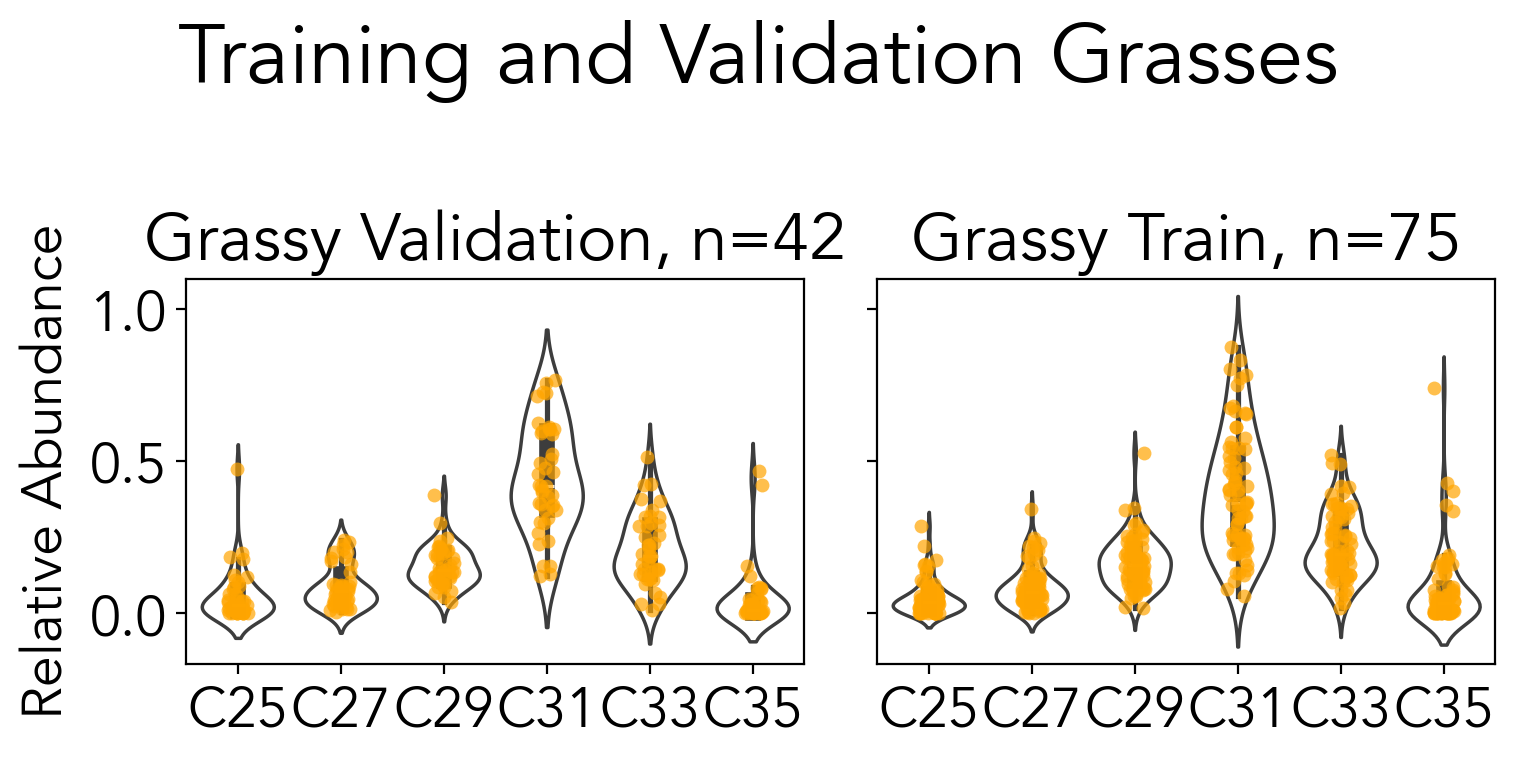

In [21]:
variables = alkanes

m = 3.5

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, sharex=True)
fig.suptitle('Training and Validation Grasses', fontsize=30)

violin_width = 0.7

grassy_test_data = sampled_grassy_rows
sns.stripplot(data = grassy_test_data[variables], ax=axes[0],  jitter=True, alpha = 0.7, color='orange', edgecolor='black')
sns.violinplot(data=grassy_test_data[variables], ax=axes[0], density_norm='width', width=violin_width, color="white")

axes[0].set_title(f'Grassy Validation, n={len(grassy_test_data)}')
axes[0].set_ylabel('Relative Abundance')

grassy_train_data = min_df[min_df['wg'] == 'Grassy'].drop(index=sampled_grassy_rows.index)
sns.stripplot(data = grassy_train_data[variables], ax=axes[1],  jitter=True, alpha = 0.7, color='orange', edgecolor='black')
sns.violinplot(data=grassy_train_data[variables], ax=axes[1], density_norm='width', width=violin_width, color="white")

axes[1].set_title(f'Grassy Train, n={len(grassy_train_data)}')
axes[1].set_ylabel('Relative Abundance')

plt.tight_layout()

plt.show()

Pulls out woody and validation data.

In [22]:
woody_subset = min_df[min_df['wg'] == 'Woody'].sample(n=woody_validation_samples, random_state=42)
grassy_subset = min_df.loc[sampled_grassy_rows.index]

min_df['split'] = 'train'
min_df.loc[woody_subset.index, 'split'] = 'test'
min_df.loc[grassy_subset.index, 'split'] = 'test'

In [23]:
test_df = min_df[min_df['split'] == 'test']

train_df = min_df[min_df['split'] == 'train']

In [24]:
train_df

,source,ID,species,loc_sure,lon,lat,altitude,family,subfam,dom,...,notes,wg,photo_subfam,clr1,clr2,clr3,clr4,clr5,clr6,split
0,This Study,KU819,Eragrostis sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,Grassy,C4 Aristidoideae,-1.556634,-0.330891,0.049928,0.984478,1.601485,-0.748366,train
2,This Study,KU821,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,Grassy,C4 Aristidoideae,-0.599286,0.208202,0.720406,1.342197,0.506745,-2.178264,train
3,This Study,KU823,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,Grassy,C4 Aristidoideae,-0.843636,0.178409,0.927436,1.497981,0.614922,-2.375112,train
4,This Study,KU824,Aristida mutabilis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,Grassy,C4 Aristidoideae,0.204837,0.545220,0.345018,1.305671,-0.052425,-2.348321,train
6,This Study,KU832,Aristida adscensionis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,Grassy,C4 Aristidoideae,-0.387803,0.707822,1.393839,1.981416,0.156029,-3.851304,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
617,Vogts et al. (2009),NaN,Ziziphus mucronata,Y,13.767000,-18.483000,NaN,Rhamnaceae,NaN,A,...,NaN,Woody,NaN,-0.727176,1.245467,0.559489,0.535391,-0.539124,-1.074047,train
618,Vogts et al. (2009),NaN,Oncoba spinosa,N,-3.430000,10.840000,NaN,Salicaceae,NaN,A,...,NaN,Woody,NaN,-3.386140,-5.773154,4.590033,5.418273,3.324691,-4.173704,train
621,Vogts et al. (2009),NaN,Ficus ottoniifolia,Y,13.470000,0.850000,NaN,Moraceae,NaN,A,...,NaN,Woody,NaN,-0.146680,0.820904,3.233240,2.746611,0.276177,-6.930252,train
622,Vogts et al. (2009),NaN,Psychotria djumaensis,Y,13.970000,1.012000,NaN,Rubiaceae,NaN,A,...,NaN,Woody,NaN,-0.872679,0.973148,4.055782,2.147746,-1.278144,-5.025853,train


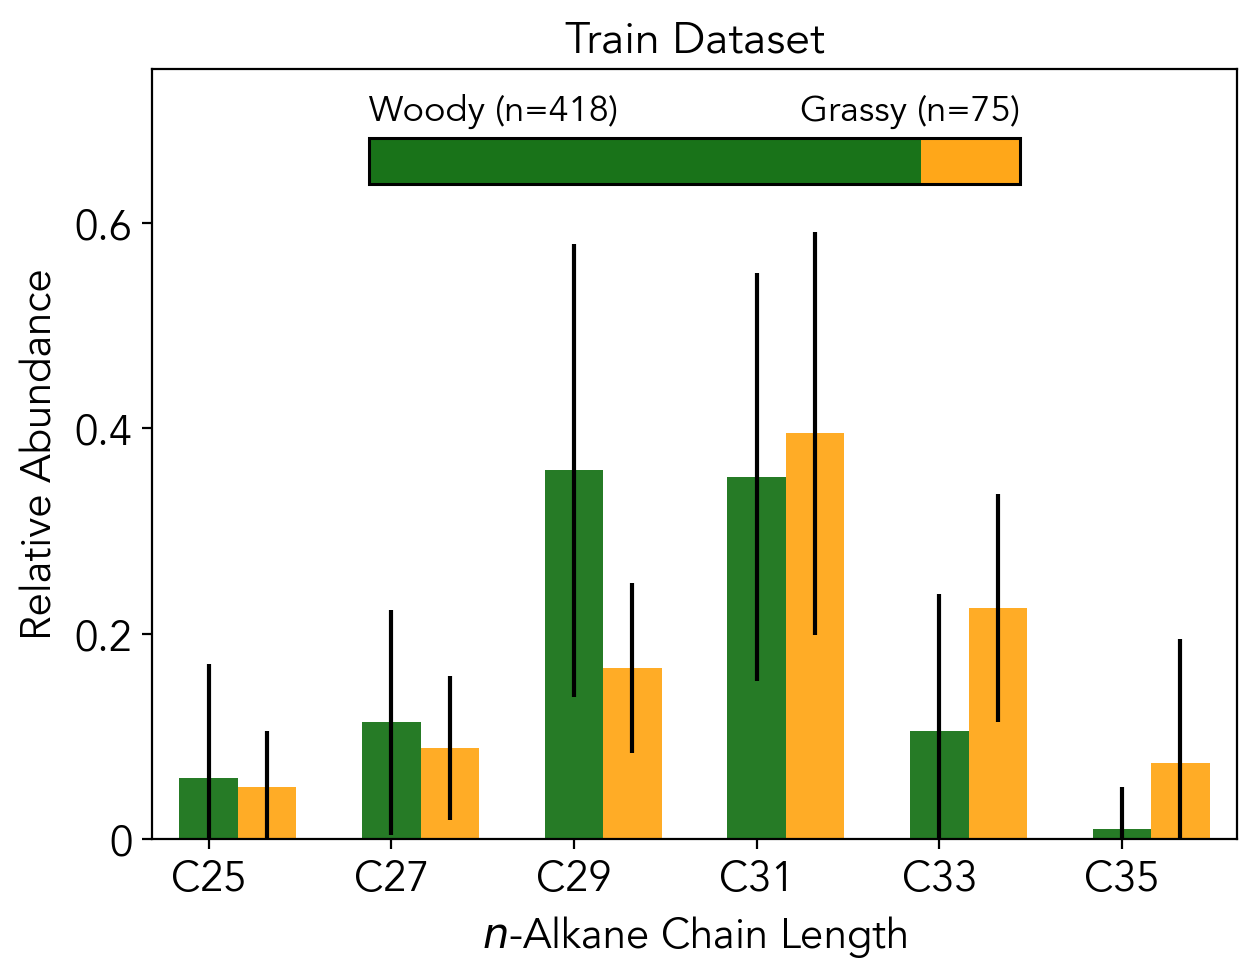

In [25]:
fig, ax = alkane_barplot_with_composition_bar(
    train_df,
    title='Train Dataset',
    ylim=(0, 0.75),
    compbar_xy=(0.2, 0.85),
    compbar_width=0.6
)

plt.show()

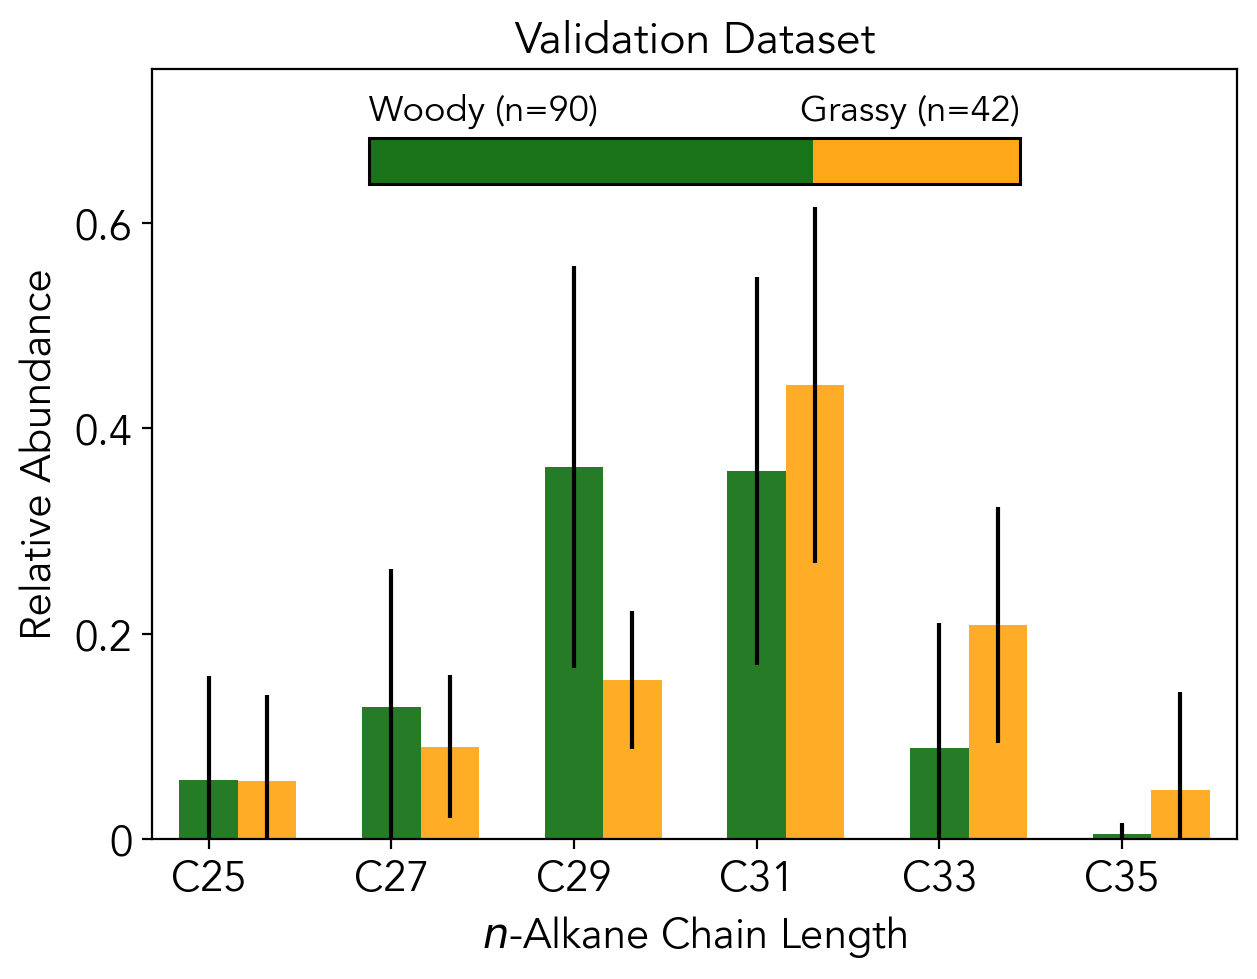

In [26]:
fig,ax = alkane_barplot_with_composition_bar(
    test_df,
    title= 'Validation Dataset',
    ylim=(0, 0.75),
    compbar_xy=(0.2, 0.85),
    compbar_width=0.6
)

plt.show()

Code below is for reducing training dataset size, if running keep_this_fraction not equal to 1.

In [27]:
from sklearn.model_selection import train_test_split

if 0 < keep_this_fraction < 1:
    train_df, _ = train_test_split(
        train_df,
        train_size=keep_this_fraction,
        stratify=train_df["pft"],
        random_state=42
    )
elif keep_this_fraction == 1:
    train_df = train_df.copy()
else:
    raise ValueError("keep_this_fraction must be in the interval (0, 1].")

# SMOTE Validation and Train Datasets

In [28]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 42)
train_data_x_res, train_data_y_res = sm.fit_resample(train_df[alkanes], train_df.wg)
test_data_x_res, test_data_y_res = sm.fit_resample(test_df[alkanes], test_df.wg)


In [29]:
synthetic_train_x = pd.concat([train_data_x_res, train_df[alkanes]]).drop_duplicates(keep=False)
synthetic_train_y = train_data_y_res.loc[synthetic_train_x.index]

synthetic_test_x = pd.concat([test_data_x_res, test_df[alkanes]]).drop_duplicates(keep=False)
synthetic_test_y = test_data_y_res.loc[synthetic_test_x.index]

In [30]:
# Create a boolean mask where train_data_y_df is 'Grassy'
mask = (min_df.wg == 'Grassy')

# Use the mask to filter train_data_x_df and create grassy_df
grassy_df = min_df[mask]
woody_df = min_df[~mask]

In [31]:
mean_real = grassy_df[alkanes].mean().values
std_real = grassy_df[alkanes].std().values

train_mask = (np.abs(synthetic_train_x.values - mean_real) < 2 * std_real).all(axis=1)
test_mask = (np.abs(synthetic_test_x.values - mean_real) < 2 * std_real).all(axis=1)

synthetic_train_x_filtered = synthetic_train_x[train_mask]
bad_synthetic_train_x = synthetic_train_x[~train_mask]
synthetic_train_y_filtered = synthetic_train_y[train_mask]
bad_synthetic_train_y = synthetic_train_y[~train_mask]

synthetic_test_x_filtered = synthetic_test_x[test_mask]
bad_synthetic_test_x = synthetic_test_x[~test_mask]
synthetic_test_y_filtered = synthetic_test_y[test_mask]
bad_synthetic_test_y = synthetic_test_y[~test_mask]

The below cells should be essentially = 1.

In [32]:
synthetic_train_x_filtered.sum(axis=1).max()

1.0009361547741609

In [33]:
synthetic_train_x_filtered.sum(axis=1).min()

0.999

In [34]:
synthetic_train_x_filtered = synthetic_train_x_filtered.copy()
synthetic_train_x_filtered['wg'] = 'Grassy'
synthetic_train_x_filtered['split'] = 'synthetic_train'

synthetic_test_x_filtered = synthetic_test_x_filtered.copy()
synthetic_test_x_filtered['wg'] = 'Grassy'
synthetic_test_x_filtered['split'] = 'synthetic_test'

missing_columns = [col for col in min_df.columns if col not in synthetic_train_x_filtered.columns]

missing_columns_df_train = pd.DataFrame(columns=missing_columns, index=synthetic_train_x_filtered.index)

missing_columns_df_test = pd.DataFrame(columns=missing_columns, index=synthetic_test_x_filtered.index)

synthetic_train_df = pd.concat([missing_columns_df_train, synthetic_train_x_filtered], axis=1, sort=False)

synthetic_test_df = pd.concat([missing_columns_df_test, synthetic_test_x_filtered], axis=1, sort=False)

combo_df = pd.concat([train_df, test_df, synthetic_train_df, synthetic_test_df], axis=0, sort=False)

combo_df.reset_index(drop=True, inplace=True)


In [35]:
train_df = combo_df[(combo_df['split'] == 'train') | (combo_df['split'] == 'synthetic_train')].reset_index()
test_df = combo_df[(combo_df['split'] == 'test') | (combo_df['split'] == 'synthetic_test')].reset_index()

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def alkane_barplot_with_composition_bar(
    df,
    alkanes=alkanes,
    wg_col="wg",
    woody_label="Woody",
    grassy_label="Grassy",
    species_col="species",
    missing_dot_color="black",
    colors=None,
    figsize=(7,5),
    width=0.32,
    ylim=(0, 0.65),
    title=None,
    compbar_height=0.06,
    compbar_width=0.52,
    compbar_xy=(0.42, 0.92),
    compbar_fontsize=13,
    bar_alpha=0.85,
):

    if colors is None:
        colors = {woody_label: "darkgreen", grassy_label: "#FF9E00"}

    # --- split ---
    woody  = df[df[wg_col] == woody_label]
    grassy = df[df[wg_col] == grassy_label]

    # --- counts & proportions ---
    n_w = len(woody)
    n_g = len(grassy)
    n_tot = n_w + n_g
    if n_tot == 0:
        raise ValueError("No Woody or Grassy samples in this dataset.")

    frac_w = n_w / n_tot
    frac_g = n_g / n_tot

    # --- within-grassy fraction missing species ---
    if (n_g > 0) and (species_col in grassy.columns):
        frac_g_missing_species = float(grassy[species_col].isna().mean())
    else:
        frac_g_missing_species = 0.0

    # --- stats ---
    w_bar = np.array([woody[a].mean() for a in alkanes], dtype=float)
    w_std = np.array([woody[a].std(ddof=0) for a in alkanes], dtype=float)
    g_bar = np.array([grassy[a].mean() for a in alkanes], dtype=float)
    g_std = np.array([grassy[a].std(ddof=0) for a in alkanes], dtype=float)

    # --- plot ---
    N = len(alkanes)
    ind = np.arange(N)
    fig, ax = plt.subplots(figsize=figsize)

    # bars (no outlines)
    ax.bar(
        ind, w_bar, width,
        yerr=w_std,
        color=colors[woody_label],
        alpha=bar_alpha,
        align="edge",
        edgecolor="none",
        linewidth=0
    )

    ax.bar(
        ind + width, g_bar, width,
        yerr=g_std,
        color=colors[grassy_label],
        alpha=bar_alpha,
        align="edge",
        edgecolor="none",
        linewidth=0
    )

    ax.set_xlabel(r"$n$-Alkane Chain Length", fontsize=15, fontweight="bold")
    ax.set_ylabel("Relative Abundance", fontsize=15, fontweight="bold")
    if title:
        ax.set_title(title, fontsize=16)

    ax.set_xticks(ind + width/2)
    ax.set_xticklabels(alkanes, fontsize=15)
    ax.tick_params(axis="y", labelsize=15)

    left_edge  = ind.min()
    right_edge = (ind.max() + width) + width
    pad = 0.15
    ax.set_xlim(left_edge - pad, right_edge + pad)
    ax.set_ylim(*ylim)
    ax.set_yticks([0, 0.2, 0.4, 0.6])
    ax.set_yticklabels(["0", "0.2", "0.4", "0.6"], fontsize=15)

    x0, y0 = compbar_xy
    W = compbar_width
    H = compbar_height

    ax.add_patch(Rectangle(
        (x0, y0), W * frac_w, H,
        transform=ax.transAxes,
        facecolor=colors[woody_label],
        edgecolor="none", alpha=0.9,
        zorder=9,
        clip_on=False
    ))
    ax.add_patch(Rectangle(
        (x0 + W * frac_w, y0), W * frac_g, H,
        transform=ax.transAxes,
        facecolor=colors[grassy_label],
        edgecolor="none", alpha=0.9,
        zorder=9,
        clip_on=False
    ))

    if (frac_g > 0) and (frac_g_missing_species > 0):
        dot_w = W * frac_g * frac_g_missing_species
        dot_x0 = x0 + W * frac_w

        if dot_w > 1e-9:
            nx = max(6, int(100 * dot_w))
            ny = 5

            xs = np.linspace(dot_x0 + 0.01*dot_w, dot_x0 + dot_w - 0.01*dot_w, nx)
            ys = np.linspace(y0 + 0.15*H,       y0 + H - 0.15*H,       ny)
            XX, YY = np.meshgrid(xs, ys)

            ax.scatter(
                XX.ravel(), YY.ravel(),
                transform=ax.transAxes,
                s=4,\
                c=missing_dot_color,
                linewidths=0,
                zorder=50,
                clip_on=False
            )

    ax.add_patch(Rectangle(
        (x0, y0), W, H,
        transform=ax.transAxes,
        facecolor="none",
        edgecolor="black",
        linewidth=1.1,
        zorder=60,
        clip_on=False
    ))

    woody_txt  = f"{woody_label} (n={n_w})"
    grassy_txt = f"{grassy_label} (n={n_g})"

    ax.text(
        x0, y0 + H + 0.01,
        woody_txt,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=compbar_fontsize,
        color="black",
        fontweight="bold",
        zorder=80
    )

    ax.text(
        x0 + W, y0 + H + 0.01,
        grassy_txt,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=compbar_fontsize,
        color="black",
        fontweight="bold",
        zorder=80
    )

    plt.show()
    return fig, ax

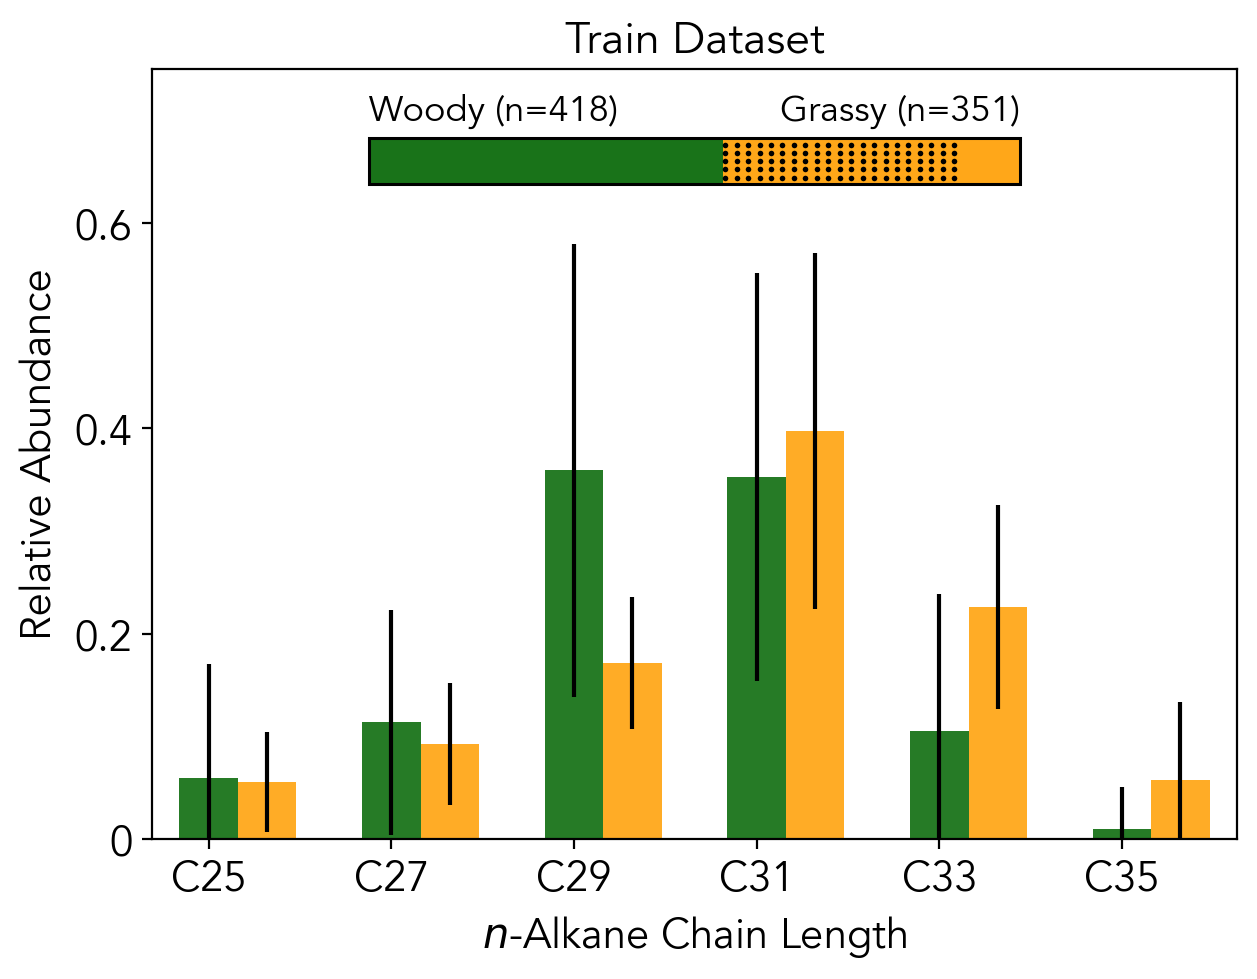

In [37]:
fig, ax = alkane_barplot_with_composition_bar(
    train_df,
    title='Train Dataset',
    ylim=(0, 0.75),
    compbar_xy=(0.2, 0.85),
    compbar_width=0.6
)

plt.show()

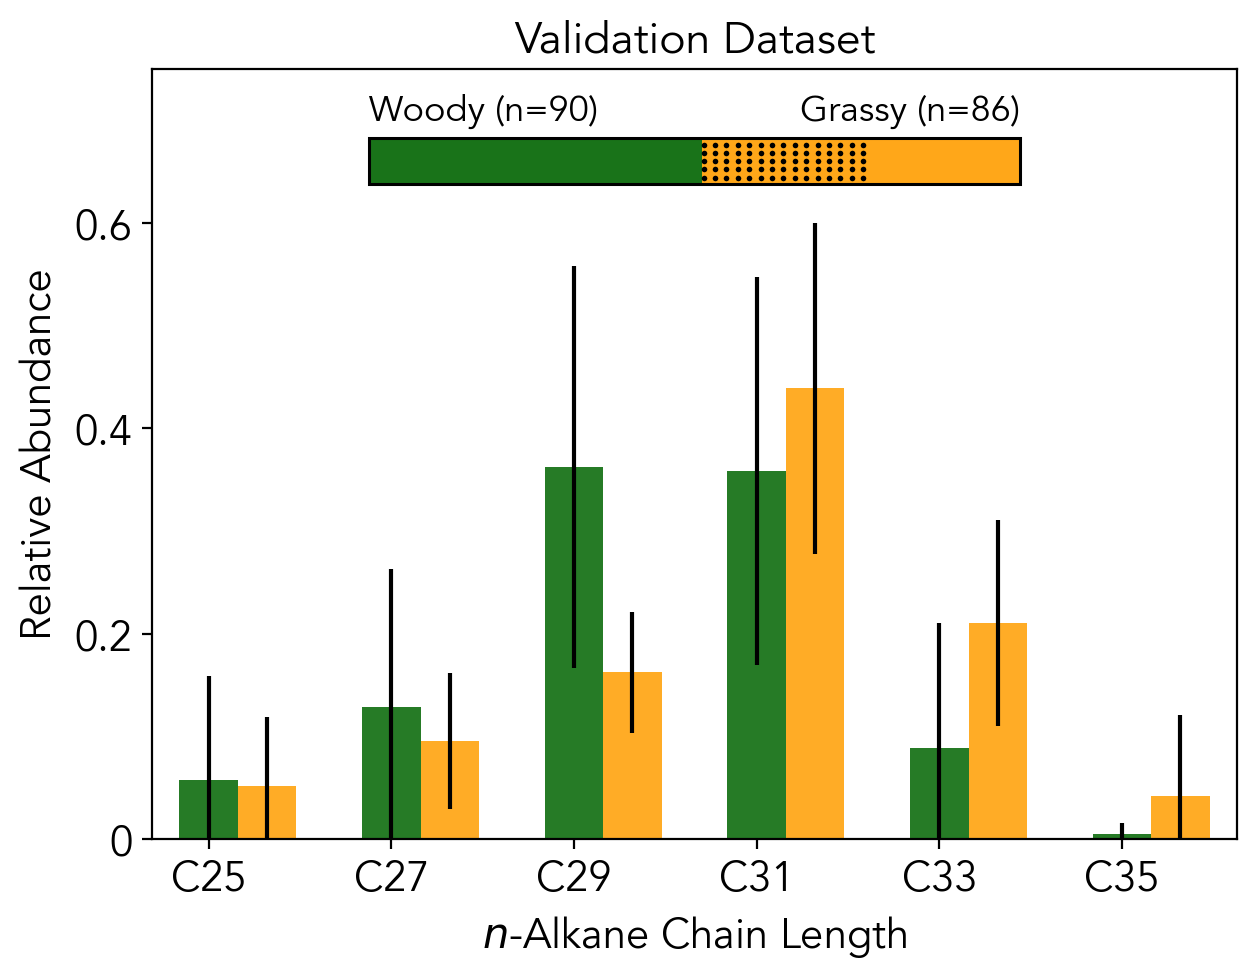

In [38]:
fig, ax = alkane_barplot_with_composition_bar(
    test_df,
    title='Validation Dataset',
    ylim=(0, 0.75),
    compbar_xy=(0.2, 0.85),
    compbar_width=0.6
)

plt.show()

In [39]:
train_wt = train_df[alkanes].fillna(0).to_numpy()
test_wt = test_df[alkanes].fillna(0).to_numpy()

# Apply Centered Log-Ratio Transformation

In [40]:
result_df = pd.concat([train_df, test_df], ignore_index=True)

In [41]:
wt = result_df[alkanes].fillna(0).to_numpy()

array_norm_clr = clr(wt)
clr_df = pd.DataFrame(array_norm_clr)

In [42]:
result_df[clrs] = clr_df

In [43]:
result_df

,index,source,ID,species,loc_sure,lon,lat,altitude,family,subfam,...,notes,wg,photo_subfam,clr1,clr2,clr3,clr4,clr5,clr6,split
0,0,This Study,KU819,Eragrostis sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,...,NaN,Grassy,C4 Aristidoideae,-1.556634,-0.330891,0.049928,0.984478,1.601485,-0.748366,train
1,1,This Study,KU821,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,...,NaN,Grassy,C4 Aristidoideae,-0.599286,0.208202,0.720406,1.342197,0.506745,-2.178264,train
2,2,This Study,KU823,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,...,NaN,Grassy,C4 Aristidoideae,-0.843636,0.178409,0.927436,1.497981,0.614922,-2.375112,train
3,3,This Study,KU824,Aristida mutabilis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,...,NaN,Grassy,C4 Aristidoideae,0.204837,0.545220,0.345018,1.305671,-0.052425,-2.348321,train
4,4,This Study,KU832,Aristida adscensionis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,...,NaN,Grassy,C4 Aristidoideae,-0.387803,0.707822,1.393839,1.981416,0.156029,-3.851304,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Grassy,NaN,-1.014830,-0.808296,-0.166907,1.217938,1.082994,-0.310898,synthetic_test
941,941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Grassy,NaN,-1.577296,0.051581,0.944968,2.312541,0.976251,-2.708045,synthetic_test
942,942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Grassy,NaN,-1.000960,-0.545139,0.016881,1.357799,0.909765,-0.738345,synthetic_test
943,943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Grassy,NaN,-0.712372,-0.485431,-0.030177,0.824862,0.841054,-0.437936,synthetic_test


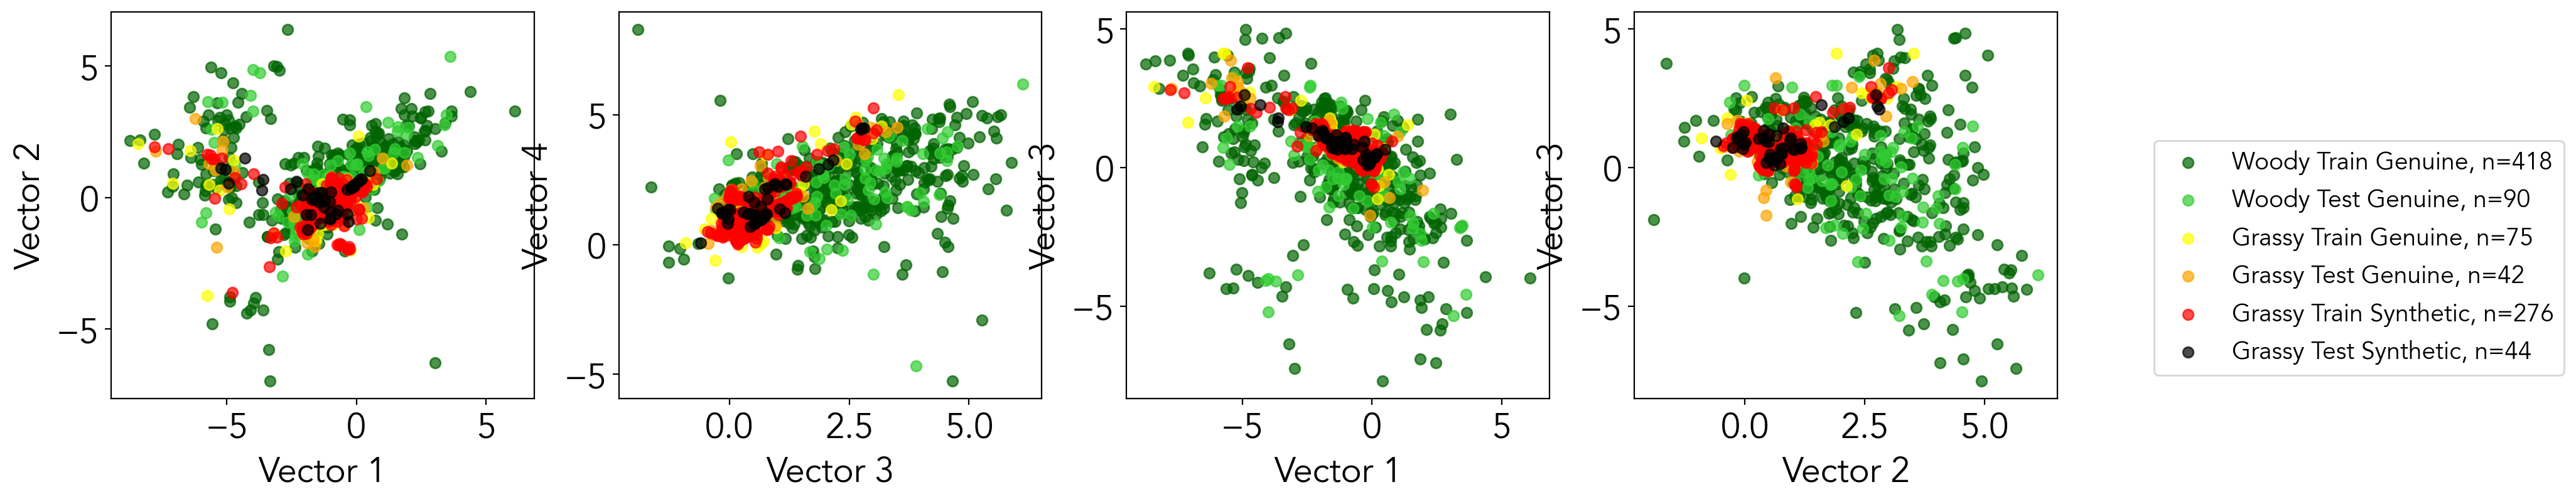

In [44]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
ax = ax.flatten()

groups = [
    ("Woody", "train", "darkgreen", "Woody Train Genuine"),
    ("Woody", "test", "limegreen", "Woody Test Genuine"),
    ("Grassy", "train", "yellow", "Grassy Train Genuine"),
    ("Grassy", "test", "orange", "Grassy Test Genuine"),
    ("Grassy", "synthetic_train", "red", "Grassy Train Synthetic"),
    ("Grassy", "synthetic_test", "black", "Grassy Test Synthetic"),
]

vector_pairs = [
    ("clr1", "clr2", "Vector 1", "Vector 2"),
    ("clr3", "clr4", "Vector 3", "Vector 4"),
    ("clr1", "clr5", "Vector 1", "Vector 3"),
    ("clr3", "clr5", "Vector 2", "Vector 3"),
]

subsets = {
    (wg, split): result_df[(result_df["wg"] == wg) & (result_df["split"] == split)]
    for wg, split, color, label in groups
}

for axis, (xcol, ycol, xlabel, ylabel) in zip(ax, vector_pairs):
    for wg, split, color, label in groups:
        subset = subsets[(wg, split)]
        axis.scatter(subset[xcol], subset[ycol], c=color, alpha=0.7)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)

legend_labels = [
    f"{label}, n={len(subsets[(wg, split)])}"
    for wg, split, color, label in groups
]

ax[3].legend(legend_labels, bbox_to_anchor=(1.2, 0.7), fontsize=14)

In [45]:
result_df.to_csv(output_csv)